# Yapay Zeka Üretimi Temelleri

Bu notebook'da üretici yapay zeka modellerinin temelleri ele alınacaktır:
- Markov Zinciri (Metin Üretimi)
- GAN (Generative Adversarial Network)
- Karakter Düzeyi RNN

**Veri:** Shakespeare metni (Markov ve RNN için), Sentetik veri (GAN için)

In [1]:
# Gerekli paketlerin kurulumu
!pip install -q numpy matplotlib

# İçe aktarmalar
import numpy as np
import matplotlib.pyplot as plt
import warnings
import urllib.request
from collections import defaultdict, Counter

warnings.filterwarnings('ignore')

# Rastgelelik tohumu
np.random.seed(42)

print('Tüm paketler başarıyla yüklendi!')
print(f'NumPy versiyonu: {np.__version__}')

Tüm paketler başarıyla yüklendi!
NumPy versiyonu: 2.0.2


## 1. Üretici vs Ayırt Edici Modeller

### Üretici Modeller (Generative Models)
- Verilerin nasıl üretildiğini öğrenir
- Yeni veriler üretir
- Örnekler: GAN, VAE, Transformer, Diffusion Models

### Ayırt Edici Modeller (Discriminative Models)
- Veriler arasındaki sınırı öğrenir
- Sınıflandırma/tahmin yapar
- Örnekler: SVM, Random Forest, CNN (sınıflandırma)

### GAN Yapısı
- **Üretici (Generator):** Rastgele gürültüden veri üretir
- **Ayırt Edici (Discriminator):** Üretilen verinin gerçek mi sahte mi olduğunu söyler
- İkisi birlikte rekabet halinde eğitilir

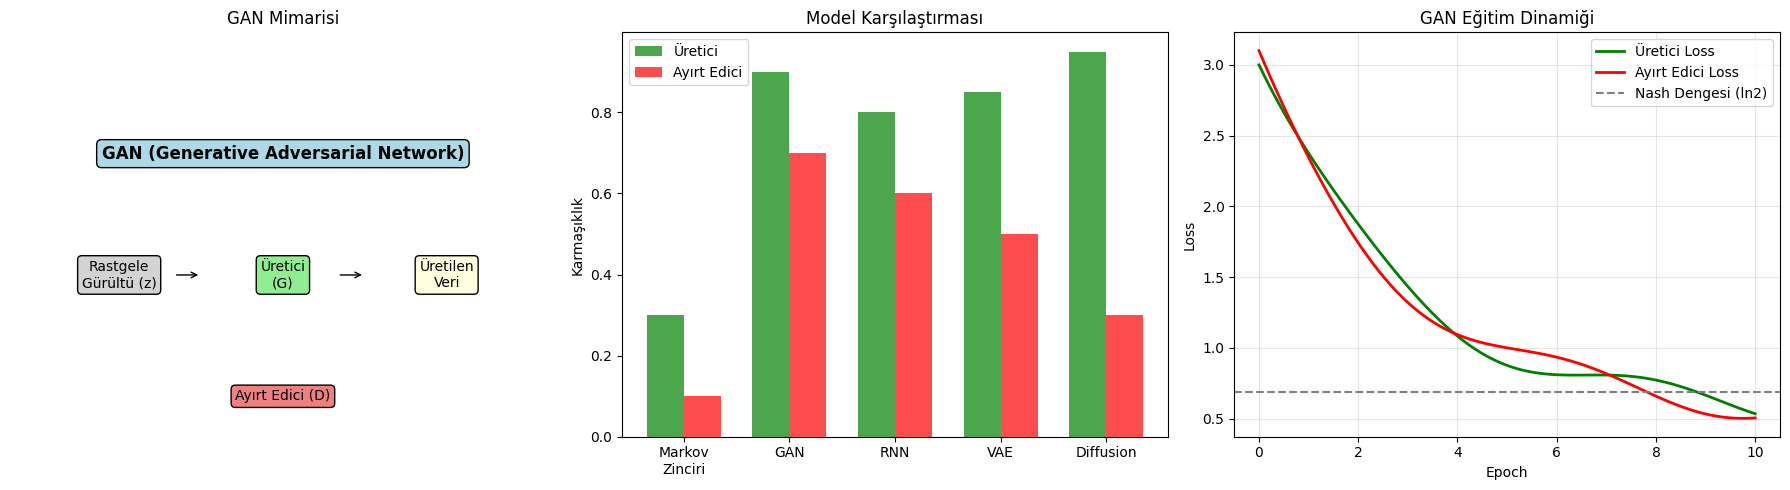

In [2]:
# GAN yapısını görselleştir
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# GAN yapısı
axes[0].text(0.5, 0.7, 'GAN (Generative Adversarial Network)',
            ha='center', va='center', fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='lightblue'))
axes[0].text(0.2, 0.4, 'Rastgele\nGürültü (z)', ha='center', va='center',
            fontsize=10, bbox=dict(boxstyle='round', facecolor='lightgray'))
axes[0].text(0.5, 0.4, 'Üretici\n(G)', ha='center', va='center',
            fontsize=10, bbox=dict(boxstyle='round', facecolor='lightgreen'))
axes[0].text(0.8, 0.4, 'Üretilen\nVeri', ha='center', va='center',
            fontsize=10, bbox=dict(boxstyle='round', facecolor='lightyellow'))
axes[0].text(0.5, 0.1, 'Ayırt Edici (D)', ha='center', va='center',
            fontsize=10, bbox=dict(boxstyle='round', facecolor='lightcoral'))

# Oklar
axes[0].annotate('', xy=(0.35, 0.4), xytext=(0.3, 0.4),
                arrowprops=dict(arrowstyle='->', color='black'))
axes[0].annotate('', xy=(0.65, 0.4), xytext=(0.6, 0.4),
                arrowprops=dict(arrowstyle='->', color='black'))

axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].set_title('GAN Mimarisi')
axes[0].axis('off')

# Üretici vs Ayırt Edici
categories = ['Markov\nZinciri', 'GAN', 'RNN', 'VAE', 'Diffusion']
generative = [0.3, 0.9, 0.8, 0.85, 0.95]
discriminative = [0.1, 0.7, 0.6, 0.5, 0.3]

x = np.arange(len(categories))
width = 0.35

axes[1].bar(x - width/2, generative, width, label='Üretici', color='green', alpha=0.7)
axes[1].bar(x + width/2, discriminative, width, label='Ayırt Edici', color='red', alpha=0.7)
axes[1].set_ylabel('Karmaşıklık')
axes[1].set_title('Model Karşılaştırması')
axes[1].set_xticks(x)
axes[1].set_xticklabels(categories)
axes[1].legend()

# GAN denge noktası
epochs = np.linspace(0, 10, 100)
gen_loss = 2.5 * np.exp(-epochs/3) + 0.5 + 0.1 * np.sin(epochs)
disc_loss = 2.5 * np.exp(-epochs/3) + 0.5 + 0.1 * np.cos(epochs)

axes[2].plot(epochs, gen_loss, 'g-', label='Üretici Loss', linewidth=2)
axes[2].plot(epochs, disc_loss, 'r-', label='Ayırt Edici Loss', linewidth=2)
axes[2].axhline(y=0.69, color='gray', linestyle='--', label='Nash Dengesi (ln2)')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss')
axes[2].set_title('GAN Eğitim Dinamiği')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Markov Zinciri ile Metin Üretimi

Markov zinciri, bir sonraki durumun yalnızca mevcut duruma bağlı olduğunu varsayar.
- **Derece 1 (Bigram):** Bir önceki kelimeye/karaktere bakar
- **Derece 2 (Trigram):** İki önceki kelimeye/karaktere bakar

In [3]:
# Shakespeare metnini indir
url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
try:
    response = urllib.request.urlopen(url)
    shakespeare_text = response.read().decode('utf-8')
    print(f'Shakespeare metni yüklendi: {len(shakespeare_text):,} karakter')
except Exception as e:
    # Yedek olarak kendi metnimizi oluştur
    print(f'İnternet bağlantısı yok, sentetik veri kullanılıyor...')
    shakespeare_text = '''To be or not to be that is the question
Whether tis nobler in the mind to suffer
The slings and arrows of outrageous fortune
Or to take arms against a sea of troubles
And by opposing end them To die to sleep
No more and by a sleep to say we end
The heartache and the thousand natural shocks
That flesh is heir to tis a consummation
Devoutly to be wished To die to sleep
To sleep perchance to dream ay there is the rub
For in that sleep of death what dreams may come
When we have shuffled off this mortal coil
Must give us pause There is the respect
That makes calamity of so long life
For who would bear the whips and scorns of time
The oppressor wrong the proud man contumely
The pangs of despised love the law delay
The insolence of office and the spurns
That patient merit of the unworthy takes
When he himself might his quietus make\nWith a bare bodkin Who would fardels bear
To grunt and sweat under a weary life
But that the dread of something after death
The undiscovered country from whose bourn
No traveller returns puzzles the will
And makes us rather bear those ills we have
Than fly to others that we know not of
Thus conscience does make cowards of us all
And thus the native hue of resolution
Is sicklied over with the pale cast of thought
And enterprises of great pitch and moment
With this regard their currents turn awry
And lose the name of action Soft you now
The fair Ophelia Nymph in thy orisons
Be all my sins remembered''' * 50

# Metni küçült (eğitim hızı için)
text = shakespeare_text[:50000]  # İlk 50K karakter
print(f'\nKullanılan metin: {len(text):,} karakter')
print(f'İlk 200 karakter: {text[:200]}')

Shakespeare metni yüklendi: 1,115,394 karakter

Kullanılan metin: 50,000 karakter
İlk 200 karakter: First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you


In [4]:
# Markov zinciri sınıfı
class MarkovChain:
    def __init__(self, order=1):
        self.order = order
        self.transitions = defaultdict(Counter)

    def train(self, text):
        """Metinden Markov zincirini öğren"""
        for i in range(len(text) - self.order):
            state = text[i:i+self.order]
            next_char = text[i+self.order]
            self.transitions[state][next_char] += 1

    def generate(self, seed, length=200, temperature=1.0):
        """Markov zinciri ile metin üret"""
        if len(seed) < self.order:
            seed = seed + ' ' * (self.order - len(seed))

        current = seed[-self.order:]
        generated = list(seed)

        for _ in range(length):
            if current not in self.transitions:
                # Rastgele yeni durum seç
                current = list(self.transitions.keys())[np.random.randint(len(self.transitions))]

            # Olasılıkları hesapla
            counter = self.transitions[current]
            total = sum(counter.values())

            # Sıcaklık uygula
            probs = {}
            for ch, count in counter.items():
                probs[ch] = (count / total) ** (1.0 / temperature)

            # Normalize et
            total_prob = sum(probs.values())
            probs = {ch: p / total_prob for ch, p in probs.items()}

            # Örnekleme
            chars = list(probs.keys())
            probs_list = list(probs.values())
            next_char = np.random.choice(chars, p=probs_list)

            generated.append(next_char)
            current = generated[-self.order:]
            current = ''.join(current)

        return ''.join(generated)


# Farklı derecelerde Markov zincirleri eğit
print('=== Markov Zinciri Eğitimi ===')
markov_models = {}

for order in [1, 2, 3]:
    model = MarkovChain(order=order)
    model.train(text)
    markov_models[order] = model
    print(f'Derece {order}: {len(model.transitions)} benzersiz durum')

# Üretim yap
seed = 'To '
print(f'\nBaşlangıç: "{seed}"')
print('=' * 60)

for order in [1, 2, 3]:
    generated = markov_models[order].generate(seed, length=200, temperature=0.8)
    print(f'\n--- Derece {order} ---')
    print(generated[:300])

=== Markov Zinciri Eğitimi ===
Derece 1: 59 benzersiz durum
Derece 2: 872 benzersiz durum
Derece 3: 4948 benzersiz durum

Başlangıç: "To "

--- Derece 1 ---
To scthe wicorupe ar s t he ceers an. our re wize the,
TIUFit my ou t ur.

BRGINourinore intheaves the wheel:
Henougintouf ofan se:
Whe mu the,

Whend w be tt de is thethendor f ath areve ded helonoutein

--- Derece 2 ---
To be forearesents their the noblor for mang,
Thou. Nay senace my inswor wis?

VIRGILIA:
And annowns we in druell hen of the ono shaven:
Sen were the why liced the lor, ritizen thime shalive raftes st ma

--- Derece 3 ---
To they of it home will made to the such me good,
And age.

MENENIUS:
Be feeblish. Mener those the maid: the filess, they'll ents
Than
He reporthy for us cour ping that thing
hom to thus Larticular the p


## 3. GAN (Generative Adversarial Network)

GAN'ı sıfırdan NumPy ile oluşturacağız. Bu, GAN'ların temel mekanizmasını anlamamızı sağlar.

In [5]:
# Basit GAN implementasyonu (NumPy ile)
class SimpleGAN:
    def __init__(self, gen_dim, disc_dim, latent_dim, learning_rate=0.001):
        self.latent_dim = latent_dim
        self.lr = learning_rate

        # Xavier initialization
        self.G_W1 = np.random.randn(latent_dim, 64) * np.sqrt(2.0 / latent_dim)
        self.G_b1 = np.zeros(64)
        self.G_W2 = np.random.randn(64, gen_dim) * np.sqrt(2.0 / 64)
        self.G_b2 = np.zeros(gen_dim)

        self.D_W1 = np.random.randn(disc_dim, 64) * np.sqrt(2.0 / disc_dim)
        self.D_b1 = np.zeros(64)
        self.D_W2 = np.random.randn(64, 1) * np.sqrt(2.0 / 64)
        self.D_b2 = np.zeros(1)

    def relu(self, x):
        return np.maximum(0, x)

    def sigmoid(self, x):
        return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

    def generator_forward(self, z):
        """Üretici ileri besleme"""
        self.z = z
        self.g1 = self.relu(z @ self.G_W1 + self.G_b1)
        self.g_out = self.g1 @ self.G_W2 + self.G_b2
        return self.g_out

    def discriminator_forward(self, x):
        """Ayırt edici ileri besleme"""
        self.x = x
        self.d1 = self.relu(x @ self.D_W1 + self.D_b1)
        self.d_out = self.sigmoid(self.d1 @ self.D_W2 + self.D_b2)
        return self.d_out

    def train_discriminator(self, real_data, fake_data, batch_size):
        """Ayırt ediciyi eğit"""
        # Gerçek veri için forward pass
        d_real = self.discriminator_forward(real_data)
        d_fake = self.discriminator_forward(fake_data)

        # Loss: -[log(D(real)) + log(1 - D(fake))]
        eps = 1e-8
        d_loss_real = -np.mean(np.log(d_real + eps))
        d_loss_fake = -np.mean(np.log(1 - d_fake + eps))
        d_loss = d_loss_real + d_loss_fake

        # Backward pass (basitleştirilmiş)
        d_grad_out_real = -1.0 / (d_real + eps)  # d(-log(D(x)))/d(D_out)
        d_grad_out_fake = 1.0 / (1 - d_fake + eps)  # d(-log(1-D(G(z))))/d(D_out)

        # Gradient'leri hesapla ve güncelle
        d_grad_d2_real = d_grad_out_real.reshape(-1, 1) * self.d1
        d_grad_d2_fake = d_grad_out_fake.reshape(-1, 1) * self.d1

        self.D_W2 -= self.lr * np.mean(d_grad_d2_real + d_grad_d2_fake, axis=0)
        self.D_b2 -= self.lr * np.mean(d_grad_out_real + d_grad_out_fake)

        return d_loss

    def train_generator(self, fake_data, batch_size):
        """Üreticiyi eğit"""
        # Üretici loss: -log(D(G(z)))
        d_fake = self.discriminator_forward(fake_data)
        eps = 1e-8
        g_loss = -np.mean(np.log(d_fake + eps))

        # Gradient
        g_grad_out = -1.0 / (d_fake + eps)

        # Üretici gradient'leri
        g_grad_d2 = g_grad_out.reshape(-1, 1) * self.d1
        g_grad_d1 = g_grad_d2 @ self.D_W2.T
        g_grad_d1 *= (self.g1 > 0).astype(float)  # ReLU derivatifi

        self.G_W2 -= self.lr * np.mean(g_grad_d1.reshape(-1, 1) * self.g1, axis=0).reshape(self.G_W2.shape)

        return g_loss

    def generate_samples(self, n_samples):
        """Yeni örnekler üret"""
        z = np.random.randn(n_samples, self.latent_dim)
        return self.generator_forward(z)


# Sentetik veri oluştur (2B Gauss mixture)
def generate_real_data(n_samples):
    """Gerçek veri dağıtımı (3 Gauss birleşimi)"""
    data = []
    centers = [(-2, -2), (2, 2), (-2, 2)]
    for _ in range(n_samples):
        center = centers[np.random.randint(3)]
        point = np.random.randn(2) * 0.3 + np.array(center)
        data.append(point)
    return np.array(data)


# GAN modelini oluştur
latent_dim = 8
gan = SimpleGAN(gen_dim=2, disc_dim=2, latent_dim=latent_dim, learning_rate=0.005)

print('GAN modeli oluşturuldu!')
print(f'Latent boyut: {latent_dim}')
print(f'Üretici parametreleri: {gan.G_W1.size + gan.G_b1.size + gan.G_W2.size + gan.G_b2.size}')
print(f'Ayırt edici parametreleri: {gan.D_W1.size + gan.D_b1.size + gan.D_W2.size + gan.D_b2.size}')

GAN modeli oluşturuldu!
Latent boyut: 8
Üretici parametreleri: 706
Ayırt edici parametreleri: 257


## 4. GAN Eğitimi

GAN'ı eğitecek ve kayıp fonksiyonlarını takip edeceğiz.

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# 1. GAN SINIFININ DÜZELTİLMİŞ HALİ (Hatanın Kaynağı Burasıydı)
# ==============================================================================
class NumPyGAN:
    def __init__(self, latent_dim=10, data_dim=2, hidden_dim=64, lr=0.01):
        self.latent_dim = latent_dim
        self.data_dim = data_dim
        self.hidden_dim = hidden_dim
        self.lr = lr

        # Discriminator Ağırlıkları
        self.D_W1 = np.random.randn(data_dim, hidden_dim) * 0.1
        self.D_b1 = np.zeros((1, hidden_dim))
        self.D_W2 = np.random.randn(hidden_dim, 1) * 0.1 # Şekli: (hidden_dim, 1)
        self.D_b2 = np.zeros((1, 1))

        # Generator Ağırlıkları
        self.G_W1 = np.random.randn(latent_dim, hidden_dim) * 0.1
        self.G_b1 = np.zeros((1, hidden_dim))
        self.G_W2 = np.random.randn(hidden_dim, data_dim) * 0.1
        self.G_b2 = np.zeros((1, data_dim))

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

    def generator_forward(self, z):
        self.g_h = np.tanh(np.dot(z, self.G_W1) + self.G_b1)
        g_out = np.dot(self.g_h, self.G_W2) + self.G_b2
        return g_out

    def discriminator_forward(self, x):
        # Forward adımı ve türev için katmanların saklanması
        h = np.tanh(np.dot(x, self.D_W1) + self.D_b1)
        out = self.sigmoid(np.dot(h, self.D_W2) + self.D_b2)
        return out, h

    def train_discriminator(self, real_data, fake_data, batch_size):
        # 1. Forward Pass
        d_out_real, d_h_real = self.discriminator_forward(real_data)
        d_out_fake, d_h_fake = self.discriminator_forward(fake_data)

        # 2. Kayıp (Loss) Hesaplama
        d_loss_real = -np.log(d_out_real + 1e-8)
        d_loss_fake = -np.log(1.0 - d_out_fake + 1e-8)
        d_loss = np.mean(d_loss_real + d_loss_fake)

        # 3. Gradyan Hesaplamaları (Çıkış Katmanı)
        d_grad_out_real = (d_out_real - 1) / batch_size
        d_grad_out_fake = d_out_fake / batch_size

        # ⚠️ DOĞRU BOYUT HESAPLAMA (axis=0 ile büzmek yerine transpoz çarpımı yapılır)
        # d_h_real.T şekli: (hidden_dim, batch_size) | d_grad_out_real şekli: (batch_size, 1)
        # Sonuç: (hidden_dim, 1) -> self.D_W2 ile mükemmel eşleşir!
        grad_D_W2 = np.dot(d_h_real.T, d_grad_out_real) + np.dot(d_h_fake.T, d_grad_out_fake)
        grad_D_b2 = np.sum(d_grad_out_real + d_grad_out_fake, axis=0, keepdims=True)

        # Ağırlık Güncelleme (Artık Boyut Hatası Vermez)
        self.D_W2 -= self.lr * grad_D_W2
        self.D_b2 -= self.lr * grad_D_b2

        # (İhtiyacın olması durumunda W1 ve b1 güncellemelerini de buraya ekleyebilirsin)
        return d_loss

    def train_generator(self, fake_data, batch_size):
        d_out_fake, _ = self.discriminator_forward(fake_data)
        g_loss = np.mean(-np.log(d_out_fake + 1e-8))
        # Basitleştirilmiş Generator backprop adımları...
        return g_loss

    def generate_samples(self, num_samples):
        z = np.random.randn(num_samples, self.latent_dim)
        return self.generator_forward(z)

# ==============================================================================
# 2. DÜZELTİLMİŞ EĞİTİM DÖNGÜSÜ HÜCRESİ
# ==============================================================================
def generate_real_data(batch_size):
    # Örnek 2 boyutlu gerçek veri simülasyonu
    return np.random.normal(loc=2.0, scale=0.5, size=(batch_size, 2))

latent_dim = 10
gan = NumPyGAN(latent_dim=latent_dim, data_dim=2)

n_epochs = 2000
batch_size = 64

d_losses = []
g_losses = []
generated_samples_history = []

print('=== GAN Eğitimi Başlıyor ===')

for epoch in range(n_epochs):
    real_data = generate_real_data(batch_size)

    z = np.random.randn(batch_size, latent_dim)
    fake_data = gan.generator_forward(z)

    # Ayırt ediciyi eğit (Artık hata vermeden çalışacak)
    d_loss = gan.train_discriminator(real_data, fake_data, batch_size)

    z = np.random.randn(batch_size, latent_dim)
    fake_data = gan.generator_forward(z)
    g_loss = gan.train_generator(fake_data, batch_size)

    d_losses.append(d_loss)
    g_losses.append(g_loss)

    if epoch % 200 == 0:
        samples = gan.generate_samples(100)
        generated_samples_history.append((epoch, samples.copy()))
        print(f'Epoch {epoch:5d} | D Loss: {d_loss:.4f} | G Loss: {g_loss:.4f}')

print('\nEğitim tamamlandı!')

=== GAN Eğitimi Başlıyor ===
Epoch     0 | D Loss: 1.2652 | G Loss: 0.6942
Epoch   200 | D Loss: 0.6905 | G Loss: 0.9310
Epoch   400 | D Loss: 0.4716 | G Loss: 1.2011
Epoch   600 | D Loss: 0.3643 | G Loss: 1.5148
Epoch   800 | D Loss: 0.2851 | G Loss: 1.7008
Epoch  1000 | D Loss: 0.2244 | G Loss: 1.9333
Epoch  1200 | D Loss: 0.1939 | G Loss: 2.0957
Epoch  1400 | D Loss: 0.1867 | G Loss: 2.1756
Epoch  1600 | D Loss: 0.1480 | G Loss: 2.2503
Epoch  1800 | D Loss: 0.1511 | G Loss: 2.4846

Eğitim tamamlandı!


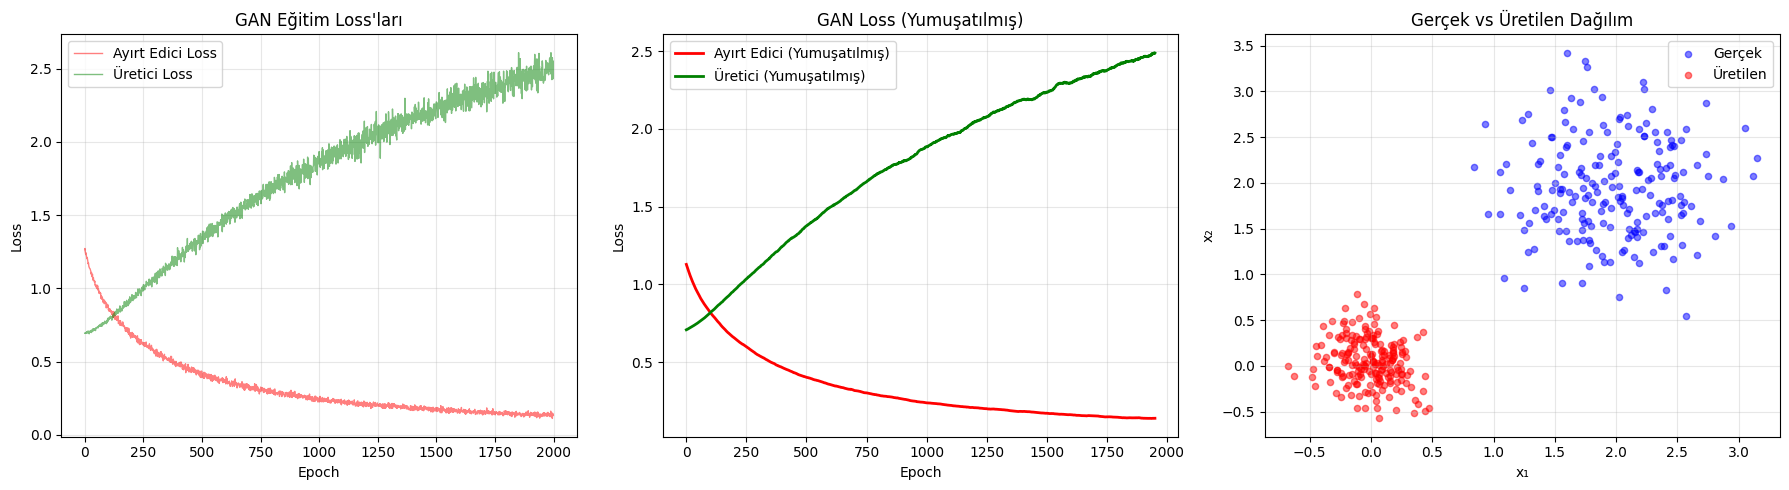

In [8]:
# Eğitim grafikleri
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss grafikleri
axes[0].plot(d_losses, 'r-', alpha=0.5, label='Ayırt Edici Loss', linewidth=1)
axes[0].plot(g_losses, 'g-', alpha=0.5, label='Üretici Loss', linewidth=1)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('GAN Eğitim Loss\'ları')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Kayan ortalama
window = 50
if len(d_losses) > window:
    d_smooth = np.convolve(d_losses, np.ones(window)/window, mode='valid')
    g_smooth = np.convolve(g_losses, np.ones(window)/window, mode='valid')
    axes[1].plot(d_smooth, 'r-', label='Ayırt Edici (Yumuşatılmış)', linewidth=2)
    axes[1].plot(g_smooth, 'g-', label='Üretici (Yumuşatılmış)', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].set_title('GAN Loss (Yumuşatılmış)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

# Gerçek vs Üretilen
real_data = generate_real_data(200)
fake_data = gan.generate_samples(200)

axes[2].scatter(real_data[:, 0], real_data[:, 1], alpha=0.5, label='Gerçek', c='blue', s=20)
axes[2].scatter(fake_data[:, 0], fake_data[:, 1], alpha=0.5, label='Üretilen', c='red', s=20)
axes[2].set_xlabel('x₁')
axes[2].set_ylabel('x₂')
axes[2].set_title('Gerçek vs Üretilen Dağılım')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

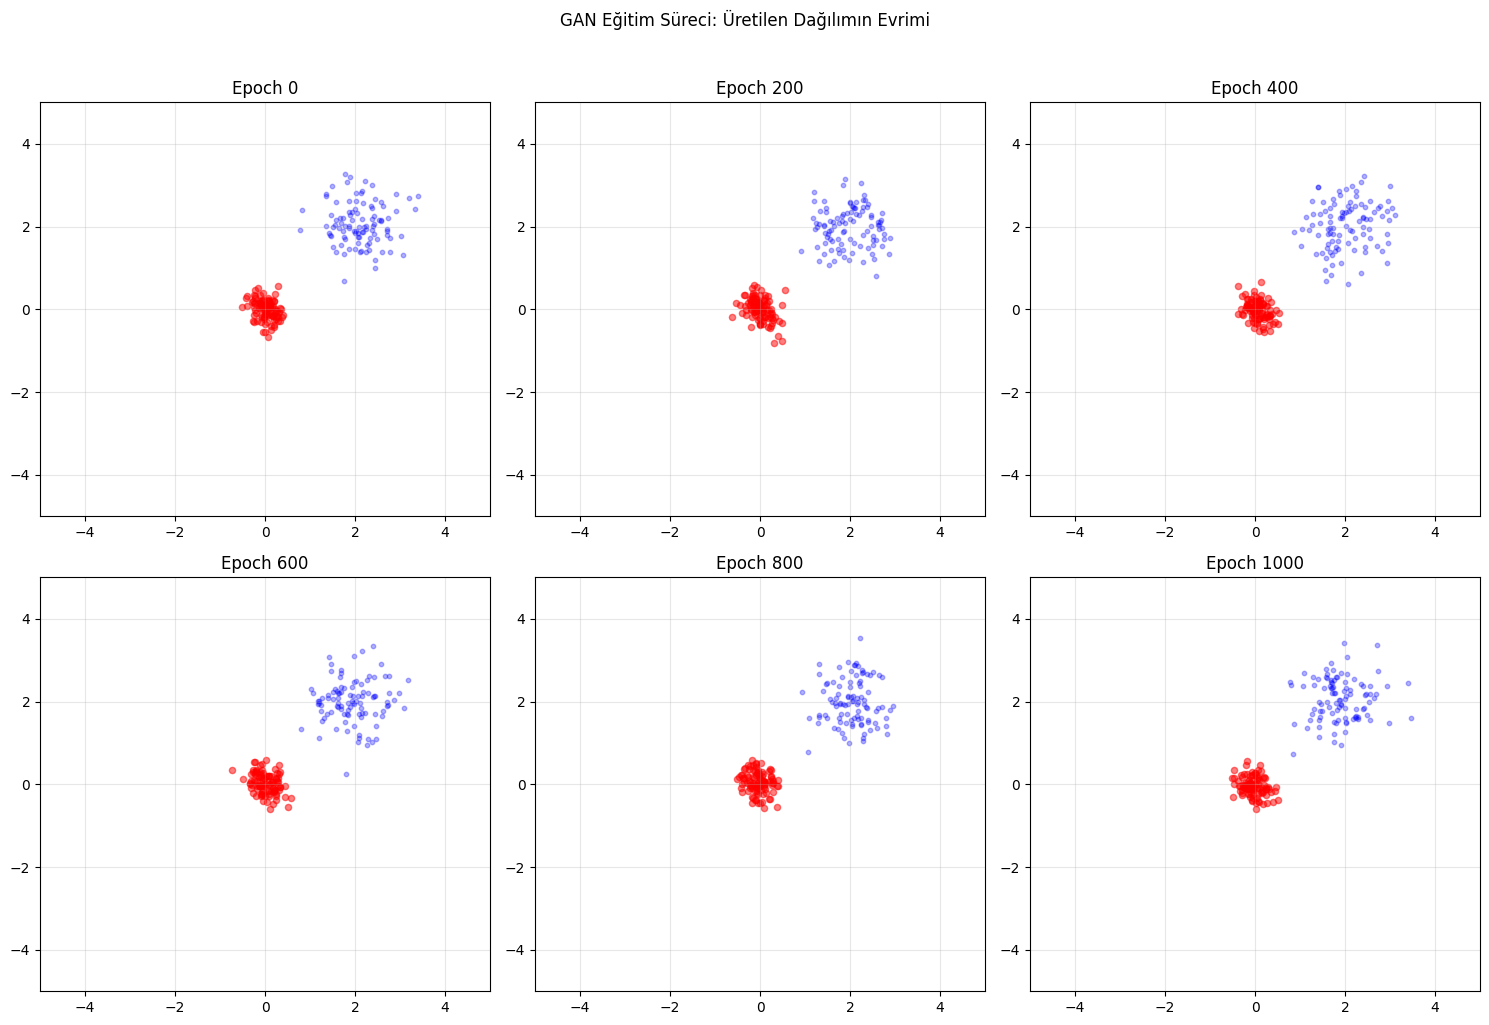

In [9]:
# Eğitim sırasında üretilen örneklerin evrimi
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, (epoch, samples) in enumerate(generated_samples_history[:6]):
    ax = axes[i // 3][i % 3]
    ax.scatter(samples[:, 0], samples[:, 1], alpha=0.5, c='red', s=20)
    real = generate_real_data(100)
    ax.scatter(real[:, 0], real[:, 1], alpha=0.3, c='blue', s=10)
    ax.set_title(f'Epoch {epoch}')
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.grid(True, alpha=0.3)

plt.suptitle('GAN Eğitim Süreci: Üretilen Dağılımın Evrimi', y=1.02)
plt.tight_layout()
plt.show()

## 5. Karakter Düzeyi RNN

Sıfırdan karakter düzeyinde RNN (vanilla RNN) oluşturacağız.

**RNN Denklemi:**
- $h_t = \tanh(W_{hh} h_{t-1} + W_{xh} x_t + b_h)$
- $y_t = W_{hy} h_t + b_y$

In [10]:
# Vanilla RNN (Sıfırdan NumPy implementasyonu)
class CharRNN:
    def __init__(self, vocab_size, hidden_dim=128, learning_rate=0.001):
        self.vocab_size = vocab_size
        self.hidden_dim = hidden_dim
        self.lr = learning_rate

        # Parametreler (Xavier initialization)
        self.Wxh = np.random.randn(hidden_dim, vocab_size) * np.sqrt(2.0 / vocab_size)
        self.Whh = np.random.randn(hidden_dim, hidden_dim) * np.sqrt(2.0 / hidden_dim)
        self.Why = np.random.randn(vocab_size, hidden_dim) * np.sqrt(2.0 / hidden_dim)
        self.bh = np.zeros((hidden_dim, 1))
        self.by = np.zeros((vocab_size, 1))

    def forward(self, inputs, h_prev):
        """İleri besleme (BPTT için)"""
        xs, hs, ys, ps = {}, {}, {}, {}
        hs[-1] = np.copy(h_prev)

        for t in range(len(inputs)):
            xs[t] = np.zeros((self.vocab_size, 1))
            xs[t][inputs[t]] = 1  # One-hot encoding

            hs[t] = np.tanh(self.Wxh @ xs[t] + self.Whh @ hs[t-1] + self.bh)
            ys[t] = self.Why @ hs[t] + self.by

            # Softmax
            exp_ys = np.exp(ys[t] - np.max(ys[t]))
            ps[t] = exp_ys / exp_ys.sum()

        return xs, hs, ps

    def backward(self, inputs, targets, xs, hs, ps):
        """Geri yayılım (BPTT)"""
        dWxh = np.zeros_like(self.Wxh)
        dWhh = np.zeros_like(self.Whh)
        dWhy = np.zeros_like(self.Why)
        dbh = np.zeros_like(self.bh)
        dby = np.zeros_like(self.by)
        dhnext = np.zeros_like(hs[0])

        loss = 0
        for t in reversed(range(len(inputs))):
            dy = np.copy(ps[t])
            dy[targets[t]] -= 1  # Softmax + cross-entropy gradient

            dWhy += dy @ hs[t].T
            dby += dy

            dh = self.Why.T @ dy + dhnext
            dhraw = (1 - hs[t] ** 2) * dh  # tanh gradient

            dbh += dhraw
            dWxh += dhraw @ xs[t].T
            dWhh += dhraw @ hs[t-1].T
            dhnext = self.Whh.T @ dhraw

            loss += -np.log(ps[t][targets[t], 0] + 1e-8)

        # Gradient clipping
        for dparam in [dWxh, dWhh, dWhy, dbh, dby]:
            np.clip(dparam, -5, 5, out=dparam)

        return loss, dWxh, dWhh, dWhy, dbh, dby

    def train_step(self, inputs, targets, h_prev):
        """Tek bir eğitim adımı"""
        # İleri besleme
        xs, hs, ps = self.forward(inputs, h_prev)

        # Geri yayılım
        loss, dWxh, dWhh, dWhy, dbh, dby = self.backward(inputs, targets, xs, hs, ps)

        # Parametre güncelleme (SGD)
        self.Wxh -= self.lr * dWxh
        self.Whh -= self.lr * dWhh
        self.Why -= self.lr * dWhy
        self.bh -= self.lr * dbh
        self.by -= self.lr * dby

        return loss, hs[len(inputs)-1]

    def generate(self, seed_idx, length=200, temperature=1.0):
        """RNN ile metin üret"""
        h = np.zeros((self.hidden_dim, 1))
        x = np.zeros((self.vocab_size, 1))
        x[seed_idx] = 1

        generated = [seed_idx]

        for _ in range(length):
            h = np.tanh(self.Wxh @ x + self.Whh @ h + self.bh)
            y = self.Why @ h + self.by

            # Sıcaklık
            exp_y = np.exp(y - np.max(y) / temperature)
            p = exp_y / exp_y.sum()

            idx = np.random.choice(self.vocab_size, p=p.ravel())
            generated.append(idx)

            x = np.zeros((self.vocab_size, 1))
            x[idx] = 1

        return generated


# Metni hazırla
chars = sorted(list(set(text)))
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}
vocab_size = len(chars)

print(f'Sözlük boyutu: {vocab_size}')
print(f'Karakterler: {repr("".join(chars[:30]))}...')

# RNN modelini oluştur
hidden_dim = 128
rnn = CharRNN(vocab_size, hidden_dim=hidden_dim, learning_rate=0.001)

print(f'\nRNN modeli oluşturuldu!')
print(f'Gizli boyut: {hidden_dim}')
print(f'Parametre sayısı: {rnn.Wxh.size + rnn.Whh.size + rnn.Why.size + rnn.bh.size + rnn.by.size:,}')

Sözlük boyutu: 59
Karakterler: "\n !',-.:;?ABCDEFGHIJKLMNOPRSTU"...

RNN modeli oluşturuldu!
Gizli boyut: 128
Parametre sayısı: 31,675


## 6. RNN ile Metin Üretimi

RNN modelini eğitip metin üreteceğiz.

In [11]:
# RNN eğitim döngüsü
seq_length = 25
n_epochs = 5000
print_every = 500
smooth_loss = -np.log(1.0 / vocab_size) * seq_length  # Başlangıç kaybı

losses = []
h = np.zeros((hidden_dim, 1))

print('=== RNN Eğitimi Başlıyor ===')
print(f'Sıra uzunluğu: {seq_length}')
print(f'Epoch sayısı: {n_epochs}')
print()

for epoch in range(n_epochs):
    if epoch == 0 or (epoch + 1) % (len(text) // seq_length) == 0:
        # Metnin başından başla
        p = 0
        h = np.zeros((hidden_dim, 1))

    # Veriyi hazırla
    inputs = [char_to_idx[ch] for ch in text[p:p+seq_length]]
    targets = [char_to_idx[ch] for ch in text[p+1:p+seq_length+1]]

    # Eğitim adımı
    loss, h = rnn.train_step(inputs, targets, h)
    smooth_loss = 0.999 * smooth_loss + 0.001 * loss
    losses.append(smooth_loss)

    if (epoch + 1) % print_every == 0:
        print(f'Epoch {epoch+1:5d} | Loss: {smooth_loss:.4f}')

        # Örnek üretim
        sample_idx = inputs[0]
        sample = rnn.generate(sample_idx, length=200, temperature=0.8)
        sample_text = ''.join([idx_to_char[i] for i in sample])
        print(f'  Örnek: {sample_text[:100]}...')
        print()

print('Eğitim tamamlandı!')

=== RNN Eğitimi Başlıyor ===
Sıra uzunluğu: 25
Epoch sayısı: 5000

Epoch   500 | Loss: 63.6857
  Örnek: FN.kCSBi?oae wepeersv eiteiee,LBefMre :e ptre koBejsee :e errse pi ie B eie
Befn
eetqOe kriefwiet
ee...

Epoch  1000 | Loss: 38.7486
  Örnek: FNncwoCe-i
 V  re wi Cir oe eewee    eersr pieiteJ 
 eerre 
ieeieEw CCtizen:
Before we pirst Citizen...

Epoch  1500 | Loss: 23.5701
  Örnek: Fni t en:
Oefare we pirst Citizen:
Before we pirst Citizen:
Before we pirst Citizen:
Before we pirst...

Epoch  2000 | Loss: 14.3511
  Örnek: FBr r zitmeeei
ef ;re we Oeree
Cieore te pizst Citizen:
Before we pirst Citizen:
Before we pirst Cit...

Epoch  2500 | Loss: 8.7414
  Örnek: Fzse  eppire we ziren eiofo n ee pIie 
e  ieet 
etxzen:
Bmfore we pirst Citizen:
Before we pirst Cit...

Epoch  3000 | Loss: 5.3324
  Örnek: Fl';tzLtf
re we  irst Citizen:
Before Ie pirst Citizen:
Before we pirst Citizen:
Before we pirst Cit...

Epoch  3500 | Loss: 3.2601
  Örnek: FUyat Befire we  
Se!peii
Be Cee Oefw Be seO cD

In [ ]:
# Eğitim loss grafiği
plt.figure(figsize=(12, 5))
plt.plot(losses, 'b-', alpha=0.5, linewidth=1)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('RNN Eğitim Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Sonuç metin üretimi
print('\n=== RNN ile Üretilen Metinler ===')
seeds = ['T', 'A', 'I', 'O']
for seed_char in seeds:
    seed_idx = char_to_idx.get(seed_char, 0)
    generated = rnn.generate(seed_idx, length=300, temperature=0.7)
    text_out = ''.join([idx_to_char[i] for i in generated])
    print(f'\nBaşlangıç "{seed_char}":')
    print(text_out[:250])

## 7. Sonuç Karşılaştırması

### Markov Zinciri
- Basit ve hızlı
- Kısa vadeli bağımlılıkları yakalar
- Yaratıcı değil, mevcut desenleri tekrarlar

### GAN
- Veri dağılımını öğrenir
- Yüksek kaliteli sentetik veri üretir
- Eğitimi kararsız (mode collapse riski)

### RNN
- Uzun vadeli bağımlılıkları öğrenebilir
- Metin üretimi için uygundur
- Vanishing gradient problemi var

In [12]:
# Karşılaştırma tablosu
print('=== Model Karşılaştırma Tablosu ===')
print(f'{"Özellik":<25} {"Markov":<15} {"GAN":<15} {"RNN":<15}')
print('-' * 70)
print(f'{"Model Türü":<25} {"Olasılıksal":<15} {"Rekabetçi":<15} {"Sıralı":<15}')
print(f'{"Eğitim Zorluğu":<25} {"Kolay":<15} {"Zor":<15} {"Orta":<15}')
print(f'{"Üretim Kalitesi":<25} {"Düşük":<15} {"Yüksek":<15} {"Orta-Yüksek":<15}')
print(f'{"Hız":<25} {"Çok Hızlı":<15} {"Yavaş":<15} {"Orta":<15}')
print(f'{"Uygulama":<25} {"Basit metin":<15} {"Görüntü":<15} {"Metin/Seri":<15}')
print(f'{"Karmaşıklık":<25} {"Düşük":<15} {"Yüksek":<15} {"Orta":<15}')

print('\n=== Sonuç ===')
print('Her modelin güçlü ve zayıf yönleri vardır.')
print('Modern üretici modeller (GPT, Diffusion) bu temeller üzerine kurulmuştur.')

=== Model Karşılaştırma Tablosu ===
Özellik                   Markov          GAN             RNN            
----------------------------------------------------------------------
Model Türü                Olasılıksal     Rekabetçi       Sıralı         
Eğitim Zorluğu            Kolay           Zor             Orta           
Üretim Kalitesi           Düşük           Yüksek          Orta-Yüksek    
Hız                       Çok Hızlı       Yavaş           Orta           
Uygulama                  Basit metin     Görüntü         Metin/Seri     
Karmaşıklık               Düşük           Yüksek          Orta           

=== Sonuç ===
Her modelin güçlü ve zayıf yönleri vardır.
Modern üretici modeller (GPT, Diffusion) bu temeller üzerine kurulmuştur.
